In [3]:
# !pip install xgboost

In [4]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# XGBoost
from xgboost import XGBRegressor

# Neural Network
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)


2026-02-04 09:36:58.927201: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-04 09:37:00.529648: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-04 09:37:04.666947: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
# Load dataset
data = fetch_california_housing(as_frame=True)

df = data.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
TARGET = "MedHouseVal"


## Initial data inspection

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
df.isna().sum()


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## EDA

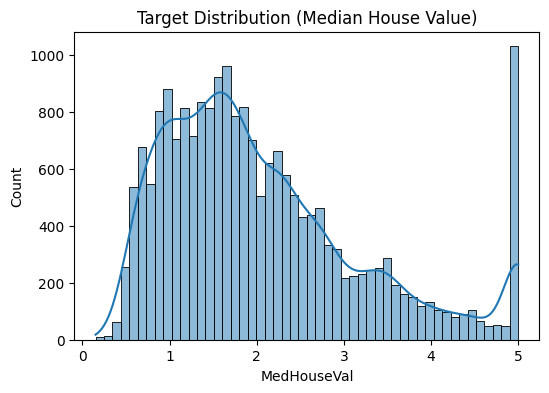

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET], bins=50, kde=True)
plt.title("Target Distribution (Median House Value)")
plt.show()


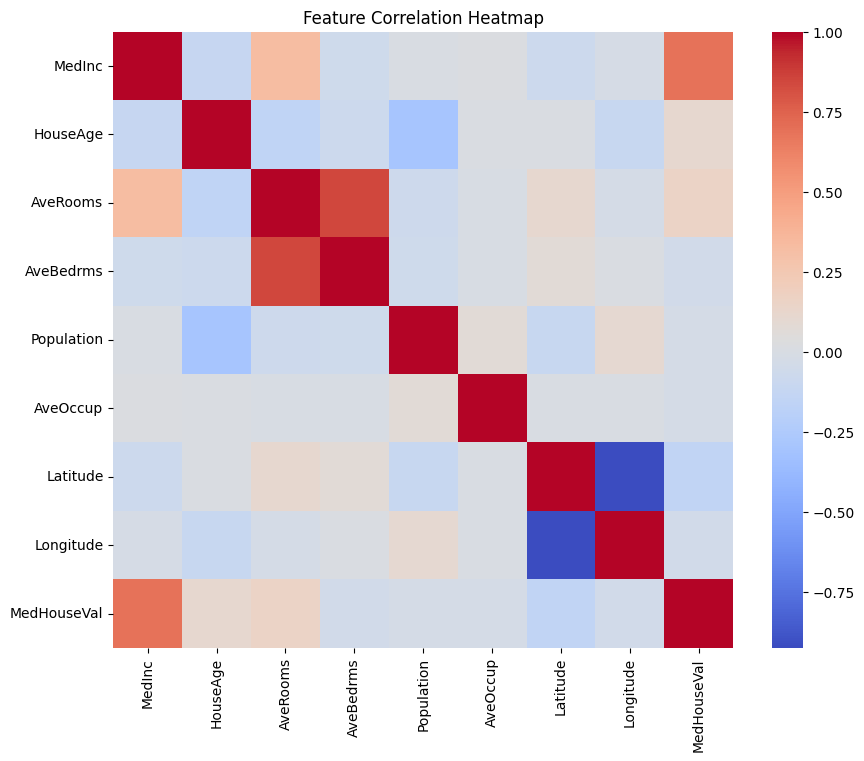

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


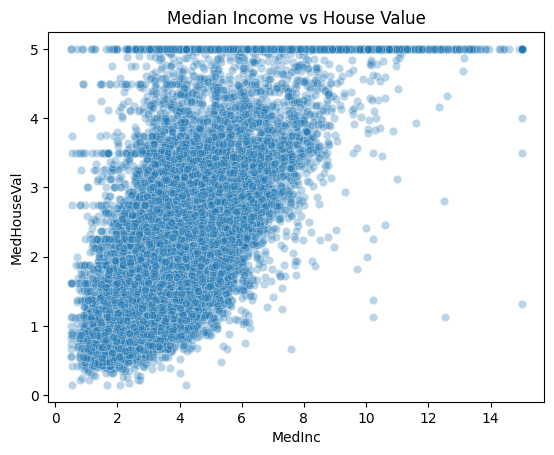

In [12]:
sns.scatterplot(x="MedInc", y=TARGET, data=df, alpha=0.3)
plt.title("Median Income vs House Value")
plt.show()


In [13]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [14]:
numeric_features = X.columns.tolist()


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ]
)


In [19]:
from sklearn.metrics import root_mean_squared_error
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)

baseline_rmse


1.1448563543099792

## Model 1 — Linear Regression (sklearn)

In [20]:
linreg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linreg_pipeline.fit(X_train, y_train)

y_pred_lr = linreg_pipeline.predict(X_test)

lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

lr_rmse, lr_mae, lr_r2


(0.7455813830127763, 0.5332001304956565, 0.575787706032451)

## Model 2 — Random Forest (sklearn)

In [24]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf)
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

rf_rmse, rf_mae, rf_r2


(0.509361923572845, 0.33217322844899017, 0.8020087060650978)

## Model 3 — XGBoost

In [25]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb)
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

xgb_rmse = root_mean_squared_error(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

xgb_rmse, xgb_mae, xgb_r2


(0.44292272783869774, 0.2908121406236475, 0.8502905992757872)

## Model 4 — Neural Network (Keras)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
X_train_scaled.shape[1]

8

In [28]:
nn_model = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

nn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

nn_model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-04 10:09:03.977395: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6784 - mae: 0.5598 - val_loss: 0.4254 - val_mae: 0.4633
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3774 - mae: 0.4326 - val_loss: 0.3894 - val_mae: 0.4382
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4088 - mae: 0.4252 - val_loss: 0.3783 - val_mae: 0.4345
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3379 - mae: 0.4082 - val_loss: 0.3516 - val_mae: 0.4073
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3159 - mae: 0.3927 - val_loss: 0.3363 - val_mae: 0.4105
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3057 - mae: 0.3857 - val_loss: 0.3172 - val_mae: 0.3844
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3079 - mae: 0.3814 - val_loss: 0.3261 - val_mae: 0.3920
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3072 - mae: 0.3798 - val_loss: 0.3360 - val_mae: 0.4007
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

In [30]:
y_pred_nn = nn_model.predict(X_test_scaled).flatten()

nn_rmse = root_mean_squared_error(y_test, y_pred_nn)
nn_mae = mean_absolute_error(y_test, y_pred_nn)
nn_r2 = r2_score(y_test, y_pred_nn)

nn_rmse, nn_mae, nn_r2


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


(0.5298377167936211, 0.3566275852461309, 0.7857706938837306)

In [31]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest", "XGBoost", "Neural Network"],
    "RMSE": [baseline_rmse, lr_rmse, rf_rmse, xgb_rmse, nn_rmse],
    "MAE": [np.nan, lr_mae, rf_mae, xgb_mae, nn_mae],
    "R2": [np.nan, lr_r2, rf_r2, xgb_r2, nn_r2]
})

results.sort_values("RMSE")


,Model,RMSE,MAE,R2
3,XGBoost,0.442923,0.290812,0.850291
2,Random Forest,0.509362,0.332173,0.802009
4,Neural Network,0.529838,0.356628,0.785771
1,Linear Regression,0.745581,0.533200,0.575788
0,Baseline,1.144856,NaN,NaN


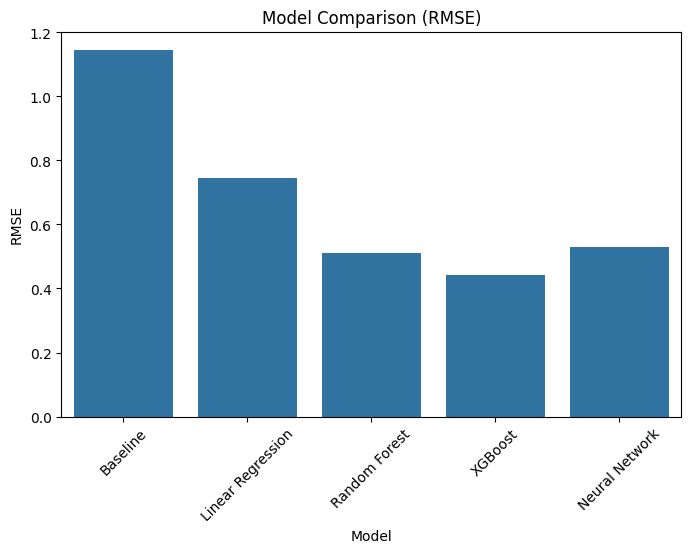

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="RMSE", data=results)
plt.xticks(rotation=45)
plt.title("Model Comparison (RMSE)")
plt.show()
